In [18]:
# Impor modul untuk akses Google Drive
from google.colab import drive

# Hubungkan Google Drive ke Colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import os
import tensorflow as tf

dataset_dir = "/content/drive/MyDrive/FNNPK"
image_size = (224, 224)

def decode_image(file_path):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    return img

def load_images_from_folder(dataset_path):
    image_list, label_list = [], []
    class_names = sorted(os.listdir(dataset_path))

    for label in class_names:
        class_folder = os.path.join(dataset_path, label)
        if not os.path.isdir(class_folder):
            continue

        for file_name in os.listdir(class_folder):
            file_path = os.path.join(class_folder, file_name)
            try:
                img = decode_image(file_path)
                img = tf.image.resize(img, image_size)
                img = tf.cast(img, tf.float32) / 255.0
                image_list.append(img)
                label_list.append(label)
            except Exception as e:
                print(f"Skipping file {file_path}: {e}")

    return image_list, label_list

# Load data
print(f"⏳ Memuat data dari {dataset_dir}...")
images, labels = load_images_from_folder(dataset_dir)
print(f"✅ Data berhasil dimuat ({len(images)} gambar).")
print("Contoh label:", labels[:10])

⏳ Memuat data dari /content/drive/MyDrive/FNNPK...
✅ Data berhasil dimuat (209 gambar).
Contoh label: ['-K', '-K', '-K', '-K', '-K', '-K', '-K', '-K', '-K', '-K']


In [20]:
import numpy as np
from collections import Counter

# Mapping label <-> angka
label2id = {label: i for i, label in enumerate(sorted(set(labels)))}
id2label = {i: label for label, i in label2id.items()}
int_labels = [label2id[l] for l in labels]

# Konversi ke numpy array
X = np.array([img.numpy() for img in images])
y = np.array(int_labels)

print("🔢 Label2ID:", label2id)
print("📊 Distribusi awal:", Counter(y))
print("🖼️ X shape:", X.shape, "y shape:", y.shape)

🔢 Label2ID: {'-K': 0, '-N': 1, '-P': 2, 'FN': 3}
📊 Distribusi awal: Counter({np.int64(0): 72, np.int64(2): 66, np.int64(1): 58, np.int64(3): 13})
🖼️ X shape: (209, 224, 224, 3) y shape: (209,)


In [21]:
from sklearn.model_selection import train_test_split
from collections import Counter

# Step 1: Split train 60% dan sisanya 40%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)

# Step 2: Split sisa 40% menjadi val dan test masing-masing 50% dari 40% → 20% dari total
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("📊 Distribusi train:", Counter(y_train))
print("📊 Distribusi val:", Counter(y_val))
print("📊 Distribusi test:", Counter(y_test))

📊 Distribusi train: Counter({np.int64(0): 43, np.int64(2): 39, np.int64(1): 35, np.int64(3): 8})
📊 Distribusi val: Counter({np.int64(2): 14, np.int64(0): 14, np.int64(1): 12, np.int64(3): 2})
📊 Distribusi test: Counter({np.int64(0): 15, np.int64(2): 13, np.int64(1): 11, np.int64(3): 3})


In [22]:
from PIL import Image

base_dir = "/content/drive/MyDrive/FNNPK_SPLIT"
for split, X_split, y_split in [("train", X_train, y_train),
                                ("val", X_val, y_val),
                                ("test", X_test, y_test)]:
    split_dir = os.path.join(base_dir, split)
    os.makedirs(split_dir, exist_ok=True)

    for idx, (img_array, label_id) in enumerate(zip(X_split, y_split)):
        label_name = id2label[label_id]
        label_folder = os.path.join(split_dir, label_name)
        os.makedirs(label_folder, exist_ok=True)

        img_pil = Image.fromarray((img_array * 255).astype(np.uint8))
        img_pil.save(os.path.join(label_folder, f"{split}_{idx}.jpg"))

print("✅ Dataset sudah disimpan ke folder FNNPK_SPLIT (train/val/test).")

✅ Dataset sudah disimpan ke folder FNNPK_SPLIT (train/val/test).


In [23]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir + "/train", image_size=(224,224), batch_size=32
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir + "/val", image_size=(224,224), batch_size=32
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir + "/test", image_size=(224,224), batch_size=32
)

print(train_ds)

Found 125 files belonging to 4 classes.
Found 42 files belonging to 4 classes.
Found 42 files belonging to 4 classes.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


Found 125 files belonging to 4 classes.


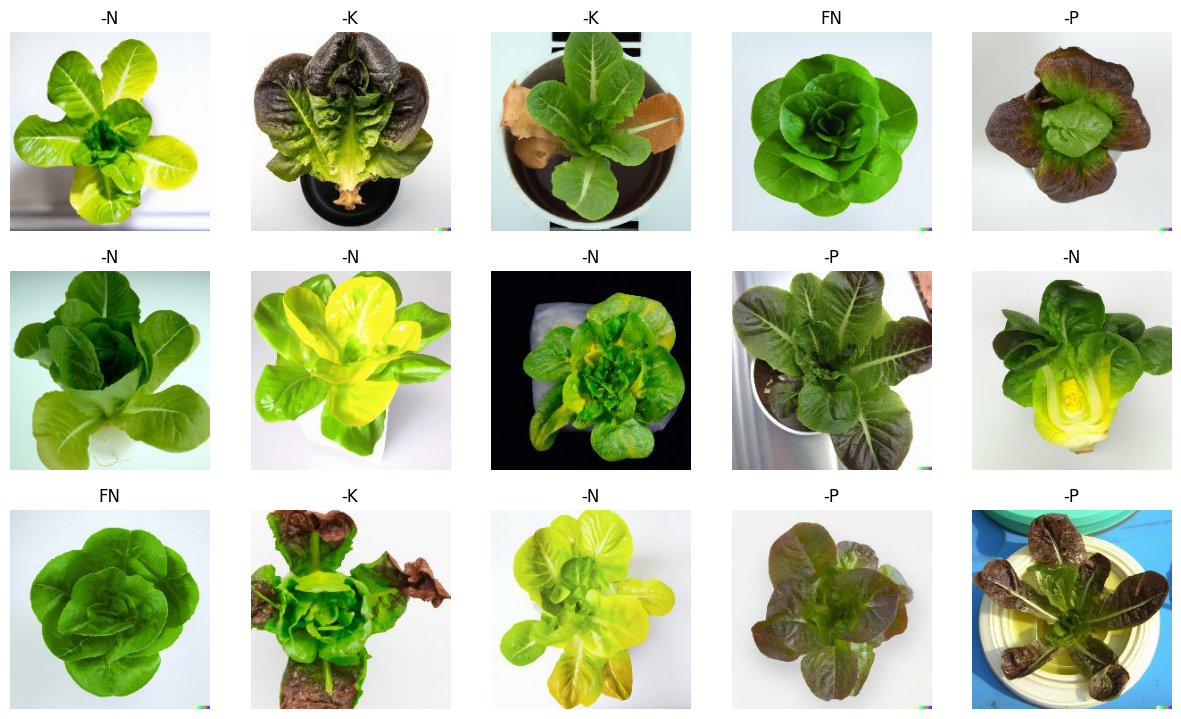

In [24]:
import matplotlib.pyplot as plt
import tensorflow as tf

# Path dataset
train_path = "/content/drive/MyDrive/FNNPK_SPLIT/train"

# Load dataset train
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="categorical",
    image_size=(224, 224),
    shuffle=True,
    seed=42,
    batch_size=16
)

# Ambil satu batch
class_names = train_ds.class_names
images, labels = next(iter(train_ds))

plt.figure(figsize=(15, 15))
for i in range(15):
    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i].numpy().argmax()])
    plt.axis("off")
plt.show()

In [25]:
import os

# Path dataset hasil split
base_dir = "/content/drive/MyDrive/FNNPK_SPLIT"

def count_images_per_class(split_dir):
    split_path = os.path.join(base_dir, split_dir)
    class_counts = {}
    for class_name in sorted(os.listdir(split_path)):
        class_folder = os.path.join(split_path, class_name)
        if os.path.isdir(class_folder):
            files = [f for f in os.listdir(class_folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
            class_counts[class_name] = len(files)
    return class_counts

# Hitung distribusi
train_counts = count_images_per_class("train")
val_counts   = count_images_per_class("val")
test_counts  = count_images_per_class("test")

# Total semua
total_images = sum(train_counts.values()) + sum(val_counts.values()) + sum(test_counts.values())

print(f"📸 Total data keseluruhan: {total_images} gambar\n")

print("📊 Distribusi data setelah split:")

print("  🟢 Train:")
for cls, count in train_counts.items():
    print(f"    {cls}: {count} gambar")

print("  🟡 Validation:")
for cls, count in val_counts.items():
    print(f"    {cls}: {count} gambar")

print("  🔵 Test:")
for cls, count in test_counts.items():
    print(f"    {cls}: {count} gambar")

📸 Total data keseluruhan: 209 gambar

📊 Distribusi data setelah split:
  🟢 Train:
    -K: 43 gambar
    -N: 35 gambar
    -P: 39 gambar
    FN: 8 gambar
  🟡 Validation:
    -K: 14 gambar
    -N: 12 gambar
    -P: 14 gambar
    FN: 2 gambar
  🔵 Test:
    -K: 15 gambar
    -N: 11 gambar
    -P: 13 gambar
    FN: 3 gambar


In [26]:
import os
from collections import Counter
import numpy as np

# base path dataset hasil split
base_dir = "/content/drive/MyDrive/FNNPK_SPLIT"
train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

# ambil daftar kelas (dari folder di train)
class_names = sorted(os.listdir(train_dir))
label2id = {c: i for i, c in enumerate(class_names)}
id2label = {i: c for c, i in label2id.items()}

print("🏷️ Mapping label:", label2id)

🏷️ Mapping label: {'-K': 0, '-N': 1, '-P': 2, 'FN': 3}


In [27]:
def load_paths_and_labels(split_dir):
    paths, labels = [], []
    for cls in sorted(os.listdir(split_dir)):
        cls_path = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        for f in os.listdir(cls_path):
            if f.lower().endswith(('.jpg','.jpeg','.png')):
                paths.append(os.path.join(cls_path, f))
                labels.append(label2id[cls])
    return paths, labels

train_paths, train_labels = load_paths_and_labels(train_dir)
val_paths, val_labels     = load_paths_and_labels(val_dir)
test_paths, test_labels   = load_paths_and_labels(test_dir)

print("📊 Jumlah data per split:")
print("  Train:", len(train_paths))
print("  Val:", len(val_paths))
print("  Test:", len(test_paths))

print("🎯 Distribusi Train:", Counter(train_labels))
print("🎯 Distribusi Val:", Counter(val_labels))
print("🎯 Distribusi Test:", Counter(test_labels))

📊 Jumlah data per split:
  Train: 125
  Val: 42
  Test: 42
🎯 Distribusi Train: Counter({0: 43, 2: 39, 1: 35, 3: 8})
🎯 Distribusi Val: Counter({0: 14, 2: 14, 1: 12, 3: 2})
🎯 Distribusi Test: Counter({0: 15, 2: 13, 1: 11, 3: 3})


In [28]:
import os
import shutil
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img, save_img

# path dataset hasil split
base_dir = "/content/drive/MyDrive/FNNPK_SPLIT"
train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

IMG_SIZE = (224, 224)

In [29]:
def oversample_class(train_dir, target_class, target_count):
    class_dir = os.path.join(train_dir, target_class)
    files = os.listdir(class_dir)
    current_count = len(files)

    if current_count >= target_count:
        print(f"✔ {target_class} sudah cukup ({current_count} gambar).")
        return

    i = 0
    while len(os.listdir(class_dir)) < target_count:
        src = os.path.join(class_dir, files[i % current_count])
        dst = os.path.join(class_dir, f"copy_{i}_{files[i % current_count]}")
        shutil.copy(src, dst)
        i += 1

    print(f"✅ Oversampling {target_class}: dari {current_count} → {len(os.listdir(class_dir))} gambar")

target_size = 50
for class_name in os.listdir(train_dir):
    oversample_class(train_dir, class_name, target_size)

✅ Oversampling -N: dari 35 → 50 gambar
✅ Oversampling -K: dari 43 → 50 gambar
✅ Oversampling -P: dari 39 → 50 gambar
✅ Oversampling FN: dari 8 → 50 gambar


In [30]:
aug_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

def augment_images(class_dir, augment_count=3):
    files = os.listdir(class_dir)
    for file in files:
        img_path = os.path.join(class_dir, file)
        img = load_img(img_path, target_size=IMG_SIZE)
        x = img_to_array(img)
        x = np.expand_dims(x, axis=0)

        # generate augment_count versi baru
        aug_iter = aug_datagen.flow(x, batch_size=1, save_to_dir=class_dir, save_prefix="aug", save_format="jpg")
        for i in range(augment_count):
            next(aug_iter)

# contoh augment semua kelas
for class_name in os.listdir(train_dir):
    print(f"🔄 Augmentasi kelas {class_name}...")
    augment_images(os.path.join(train_dir, class_name), augment_count=3)

🔄 Augmentasi kelas -N...
🔄 Augmentasi kelas -K...
🔄 Augmentasi kelas -P...
🔄 Augmentasi kelas FN...


In [31]:
train_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="categorical"
)

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="categorical"
)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 798 images belonging to 4 classes.
Found 42 images belonging to 4 classes.
Found 42 images belonging to 4 classes.


In [32]:
import os

# path dataset final
base_dir = "/content/drive/MyDrive/FNNPK_SPLIT"

def count_images(split_dir):
    split_path = os.path.join(base_dir, split_dir)
    class_counts = {}
    for cls in sorted(os.listdir(split_path)):
        class_folder = os.path.join(split_path, cls)
        if os.path.isdir(class_folder):
            files = [f for f in os.listdir(class_folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
            class_counts[cls] = len(files)
    return class_counts

train_counts = count_images("train")
val_counts   = count_images("val")
test_counts  = count_images("test")

print("📊 Distribusi data:")
print("  🟢 Train:", train_counts)
print("  🟡 Validation:", val_counts)
print("  🔵 Test:", test_counts)

print(f"\n📸 Total gambar: {sum(train_counts.values()) + sum(val_counts.values()) + sum(test_counts.values())}")

📊 Distribusi data:
  🟢 Train: {'-K': 200, '-N': 200, '-P': 199, 'FN': 199}
  🟡 Validation: {'-K': 14, '-N': 12, '-P': 14, 'FN': 2}
  🔵 Test: {'-K': 15, '-N': 11, '-P': 13, 'FN': 3}

📸 Total gambar: 882


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ====== Setup folder dataset ======
base_dir = "/content/drive/MyDrive/FNNPK_SPLIT"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# ====== Data Generator ======
train_datagen = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1
)

val_test_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_directory(
    os.path.join(base_dir, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# ====== Model EfficientNetB1 ======
input_layer = Input(shape=(224, 224, 3))
effnet = EfficientNetB1(include_top=False, weights="imagenet", input_tensor=input_layer)
effnet.trainable = False  # freeze semua layer awal

x = GlobalAveragePooling2D()(effnet.output)
x = Dropout(0.7)(x)
output = Dense(train_gen.num_classes, activation="softmax")(x)

efficient_model = Model(inputs=input_layer, outputs=output)

# ====== Compile Stage 1 (Feature Extractor) ======
efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top_2_acc")]
)

callbacks_stage1 = [
    EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
    ModelCheckpoint("efficient_stage1.keras", save_best_only=True, monitor="val_loss"),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)
]

print("=== Training Stage 1 (Feature Extraction) ===")
history_stage1 = efficient_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=callbacks_stage1,
    verbose=1
)

# ====== Stage 2a: Fine-Tuning Ringan ======
print("=== Training Stage 2a (Fine-Tuning Ringan) ===")
for layer in effnet.layers[-20:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

efficient_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top_2_acc")]
)

callbacks_stage2a = [
    EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
    ModelCheckpoint("efficient_stage2a.keras", save_best_only=True, monitor="val_loss"),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7)
]

history_stage2a = efficient_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks_stage2a,
    verbose=1
)

Found 797 images belonging to 4 classes.
Found 42 images belonging to 4 classes.
Found 42 images belonging to 4 classes.
=== Training Stage 1 (Feature Extraction) ===


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.2226 - loss: 1.8599 - top_2_acc: 0.4481 - val_accuracy: 0.2857 - val_loss: 1.4402 - val_top_2_acc: 0.5000 - learning_rate: 1.0000e-04
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 264ms/step - accuracy: 0.2872 - loss: 1.6213 - top_2_acc: 0.5361 - val_accuracy: 0.4048 - val_loss: 1.3430 - val_top_2_acc: 0.5714 - learning_rate: 1.0000e-04
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 264ms/step - accuracy: 0.3220 - loss: 1.4890 - top_2_acc: 0.5905 - val_accuracy: 0.4762 - val_loss: 1.2650 - val_top_2_acc: 0.6190 - learning_rate: 1.0000e-04
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 264ms/step - accuracy: 0.3689 - loss: 1.3894 - top_2_acc: 0.6352 - val_accuracy: 0.5000 - val_loss: 1.1986 - val_top_2_acc: 0.6667 - learning_rate: 1.0000e-04
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 262ms/step - accuracy: 0.4213 - loss: 1.2895 - top_2_acc: 0.6933 - val_accuracy: 0.5000 - val_loss: 1.1454 - val_top_2_acc: 0.7143 - learning_rate: 1.0000e-0

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# ====== Gabungkan history stage1 + stage2a ======
def combine_history(h1, h2):
    history = {}
    for key in h1.history.keys():
        history[key] = h1.history[key] + h2.history[key]
    return history

full_history = combine_history(history_stage1, history_stage2a)

# ====== Buat DataFrame ======
df_history = pd.DataFrame(full_history)
df_history.index += 1  # mulai dari epoch 1

# tampilkan per 5 epoch
print("=== Ringkasan per 5 epoch ===")
print(df_history.iloc[::5, :][["accuracy", "val_accuracy", "loss", "val_loss"]])

# ====== Cari best model (val_loss terendah) ======
best_epoch = df_history["val_loss"].idxmin()

best_val_loss = df_history.loc[best_epoch, "val_loss"]
best_val_acc  = df_history.loc[best_epoch, "val_accuracy"]
best_train_loss = df_history.loc[best_epoch, "loss"]
best_train_acc  = df_history.loc[best_epoch, "accuracy"]

print(f"\n=== Best Model (berdasarkan val_loss) ===")
print(f"Epoch        : {best_epoch}")
print(f"Train Loss   : {best_train_loss:.4f}")
print(f"Train Acc    : {best_train_acc:.4f}")
print(f"Val Loss     : {best_val_loss:.4f}")
print(f"Val Accuracy : {best_val_acc:.4f}")

=== Ringkasan per 5 epoch ===
    accuracy  val_accuracy       loss  val_loss
1   0.258469      0.333333  15.839730  6.323546
6   0.358846      0.523810   9.694695  3.882135
11  0.465496      0.595238   6.463663  2.290195
16  0.524467      0.690476   5.051586  1.560351
21  0.549561      0.761905   4.213473  1.273282
26  0.562108      0.809524   3.549574  1.209692
31  0.634881      0.809524   2.948979  1.127846
36  0.666248      0.738095   2.357018  1.185829
41  0.666248      0.809524   2.100792  1.043879
46  0.677541      0.833333   1.725027  1.021420
51  0.710163      0.833333   1.582682  0.947788
56  0.675031      0.833333   1.733160  0.967505
61  0.884567      0.857143   0.327093  0.456058
66  0.910916      0.880952   0.262781  0.408474
71  0.925972      0.904762   0.203612  0.380341
76  0.937265      0.904762   0.173307  0.364813
81  0.957340      0.904762   0.140485  0.361814
86  0.961104      0.904762   0.125783  0.364471

=== Best Model (berdasarkan val_loss) ===
Epoch        : 

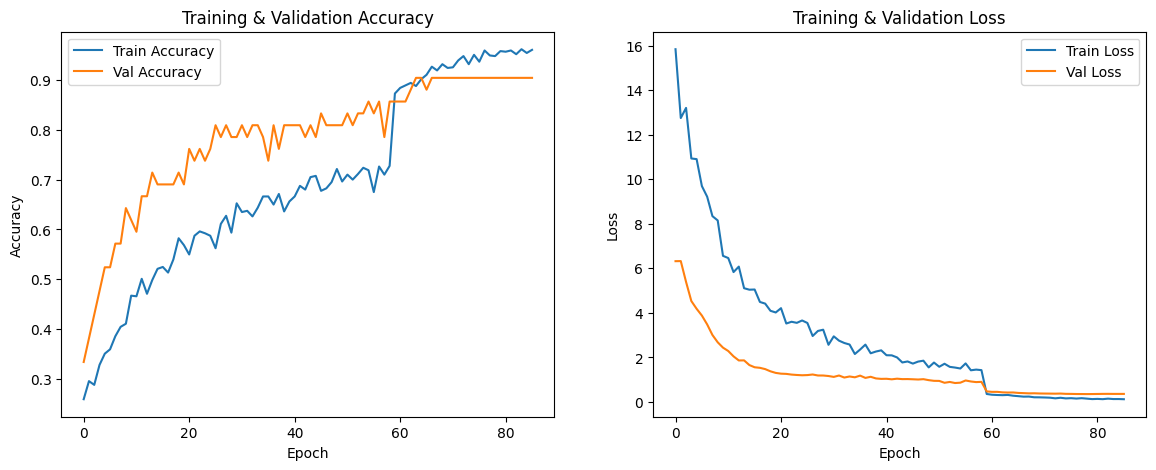

In [44]:
import matplotlib.pyplot as plt

# ==== Gabungkan history stage1 + stage2a ====
def combine_history(h1, h2):
    history = {}
    for key in h1.history.keys():
        history[key] = h1.history[key] + h2.history[key]
    return history

full_history = combine_history(history_stage1, history_stage2a)

# ==== Plot Accuracy & Loss ====
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(full_history["accuracy"], label="Train Accuracy")
plt.plot(full_history["val_accuracy"], label="Val Accuracy")
plt.title("Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(full_history["loss"], label="Train Loss")
plt.plot(full_history["val_loss"], label="Val Loss")
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.8389 - loss: 0.4587 - top_2_acc: 1.0000
Test Loss      : 0.3483
Test Accuracy  : 0.8810
Test Top-2 Acc : 1.0000
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step

=== Classification Report (Test Data) ===
              precision    recall  f1-score   support

          -K       1.00      0.80      0.89        15
          -N       0.90      0.82      0.86        11
          -P       0.87      1.00      0.93        13
          FN       0.60      1.00      0.75         3

    accuracy                           0.88        42
   macro avg       0.84      0.90      0.86        42
weighted avg       0.90      0.88      0.88        42



<Figure size 700x700 with 0 Axes>

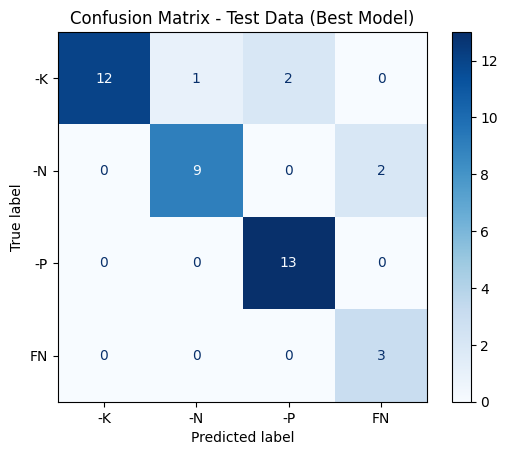

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf

# ==== Load best model dari checkpoint ====
best_model = tf.keras.models.load_model("efficient_stage2a.keras")

# ==== Evaluasi di dataset test ====
test_loss, test_acc, test_top2 = best_model.evaluate(test_gen, verbose=1)
print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test Top-2 Acc : {test_top2:.4f}")

# ==== Prediksi kelas di test set ====
test_gen.reset()
test_preds = best_model.predict(test_gen, verbose=1)
test_pred_classes = np.argmax(test_preds, axis=1)
test_true_classes = test_gen.classes

# ==== Classification Report ====
print("\n=== Classification Report (Test Data) ===")
print(classification_report(test_true_classes, test_pred_classes, target_names=test_gen.class_indices.keys()))

# ==== Confusion Matrix ====
cm = confusion_matrix(test_true_classes, test_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_gen.class_indices.keys())

plt.figure(figsize=(7, 7))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Test Data (Best Model)")
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8389 - loss: 0.4587 - top_2_acc: 1.0000
Last Model - Test Loss      : 0.3483
Last Model - Test Accuracy  : 0.8810
Last Model - Test Top-2 Acc : 1.0000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

=== Classification Report (Last Model - Test Data) ===
              precision    recall  f1-score   support

          -K       1.00      0.80      0.89        15
          -N       0.90      0.82      0.86        11
          -P       0.87      1.00      0.93        13
          FN       0.60      1.00      0.75         3

    accuracy                           0.88        42
   macro avg       0.84      0.90      0.86        42
weighted avg       0.90      0.88      0.88        42



<Figure size 700x700 with 0 Axes>

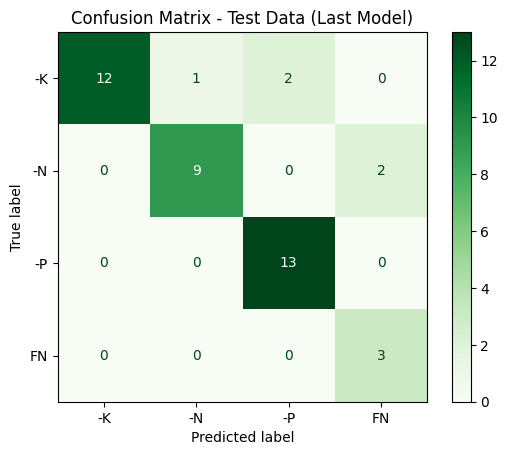

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ==== Evaluasi Last Model di dataset test ====
last_test_loss, last_test_acc, last_test_top2 = efficient_model.evaluate(test_gen, verbose=1)
print(f"Last Model - Test Loss      : {last_test_loss:.4f}")
print(f"Last Model - Test Accuracy  : {last_test_acc:.4f}")
print(f"Last Model - Test Top-2 Acc : {last_test_top2:.4f}")

# ==== Prediksi kelas di test set ====
test_gen.reset()
last_test_preds = efficient_model.predict(test_gen, verbose=1)
last_test_pred_classes = np.argmax(last_test_preds, axis=1)
last_test_true_classes = test_gen.classes

# ==== Classification Report ====
print("\n=== Classification Report (Last Model - Test Data) ===")
print(classification_report(last_test_true_classes, last_test_pred_classes, target_names=test_gen.class_indices.keys()))

# ==== Confusion Matrix ====
last_cm = confusion_matrix(last_test_true_classes, last_test_pred_classes)
last_disp = ConfusionMatrixDisplay(confusion_matrix=last_cm, display_labels=test_gen.class_indices.keys())

plt.figure(figsize=(7, 7))
last_disp.plot(cmap="Greens", values_format="d")
plt.title("Confusion Matrix - Test Data (Last Model)")
plt.show()


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB1, DenseNet121
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ====== Input ======
IMG_SIZE = (224,224,3)
num_classes = train_gen.num_classes

input_layer = tf.keras.Input(shape=IMG_SIZE)

# ====== EfficientNetB1 Backbone ======
effnet = EfficientNetB1(include_top=False, weights="imagenet", input_tensor=input_layer)
effnet.trainable = False
x_eff = layers.GlobalAveragePooling2D()(effnet.output)

# ====== DenseNet121 Backbone ======
densenet = DenseNet121(include_top=False, weights="imagenet", input_tensor=input_layer)
densenet.trainable = False
x_dense = layers.GlobalAveragePooling2D()(densenet.output)

# ====== Gabungkan feature ======
x = layers.concatenate([x_eff, x_dense])
x = layers.Dropout(0.5)(x)
output = layers.Dense(num_classes, activation="softmax")(x)

# ====== Hybrid Model ======
hybrid_model = Model(inputs=input_layer, outputs=output)

# ====== Compile tahap 1 (freeze backbone) ======
hybrid_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top_2_acc")]
)

callbacks_stage1 = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint("hybrid_stage1.keras", save_best_only=True, monitor="val_loss", verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

# ====== Training tahap 1 ======
history_stage1 = hybrid_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=callbacks_stage1,
    verbose=1
)

# ====== Fine-tuning backbone ======
trainable_layers_eff = 20
trainable_layers_dense = 20

for layer in effnet.layers[-trainable_layers_eff:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

for layer in densenet.layers[-trainable_layers_dense:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

# Compile ulang dengan learning rate lebih kecil
hybrid_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.TopKCategoricalAccuracy(k=2, name="top_2_acc")]
)

callbacks_stage2 = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint("hybrid_stage2.keras", save_best_only=True, monitor="val_loss", verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

# ====== Training tahap 2 ======
history_stage2 = hybrid_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks_stage2,
    verbose=1
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - accuracy: 0.2659 - loss: 1.5478 - top_2_acc: 0.5314
Epoch 1: val_loss improved from inf to 1.34913, saving model to hybrid_stage1.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.2661 - loss: 1.5472 - top_2_acc: 0.5318 - val_accuracy: 0.3095 - val_loss: 1.3491 - val_top_2_acc: 0.4762 - learning_rate: 1.0000e-04
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.3239 - loss: 1.4407 - top_2_acc: 0.6068
Epoch 2: val_loss improved from 1.34913 to 1.30369, saving model to hybrid_stage1.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 312ms/step - accuracy: 0.3244 - loss: 1.4397 - top_2_acc: 0.6071 - val_accuracy: 0.3333 - val_loss: 1.3037 - val_top_2_acc: 0.6429 - learning_rate: 1.0000e-04
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.3416 - loss: 1.3909 - top_2_acc: 0.6095
Epoch 3: val_loss improved from 1.30369 to 1.24537, saving model to hybrid_stage1.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 329ms/step - 

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# ====== Gabungkan history stage1 + stage2a ======
def combine_history(h1, h2):
    history = {}
    for key in h1.history.keys():
        history[key] = h1.history[key] + h2.history[key]
    return history

full_history = combine_history(history_stage1, history_stage2)

# ====== Buat DataFrame ======
df_history = pd.DataFrame(full_history)
df_history.index += 1  # mulai dari epoch 1

# tampilkan per 5 epoch
print("=== Ringkasan per 5 epoch ===")
print(df_history.iloc[::5, :][["accuracy", "val_accuracy", "loss", "val_loss"]])

# ====== Cari best model (val_loss terendah) ======
best_epoch = df_history["val_loss"].idxmin()
best_val_loss = df_history.loc[best_epoch, "val_loss"]
best_val_acc = df_history.loc[best_epoch, "val_accuracy"]

print(f"\n=== Best Model (berdasarkan val_loss) ===")
print(f"Epoch: {best_epoch}")
print(f"Val Loss: {best_val_loss:.4f}")
print(f"Val Accuracy: {best_val_acc:.4f}")

=== Ringkasan per 5 epoch ===
    accuracy  val_accuracy      loss  val_loss
1   0.274436      0.309524  1.518382  1.349131
6   0.503759      0.404762  1.082316  1.096692
11  0.620301      0.523810  0.888680  0.954938
16  0.671679      0.666667  0.808203  0.818358
21  0.736842      0.690476  0.708966  0.759024
26  0.746867      0.738095  0.633469  0.685910
31  0.785714      0.738095  0.574339  0.647251
36  0.809524      0.809524  0.557350  0.613337
41  0.809524      0.785714  0.516335  0.572502
46  0.814536      0.833333  0.513576  0.530070
51  0.819549      0.904762  0.478767  0.473421
56  0.897243      0.952381  0.285721  0.347650
61  0.943609      0.952381  0.179910  0.228383
66  0.951128      0.952381  0.132723  0.209332
71  0.959900      0.976190  0.097362  0.158371
76  0.981203      0.976190  0.075131  0.152310

=== Best Model (berdasarkan val_loss) ===
Epoch: 78
Val Loss: 0.1418
Val Accuracy: 0.9762


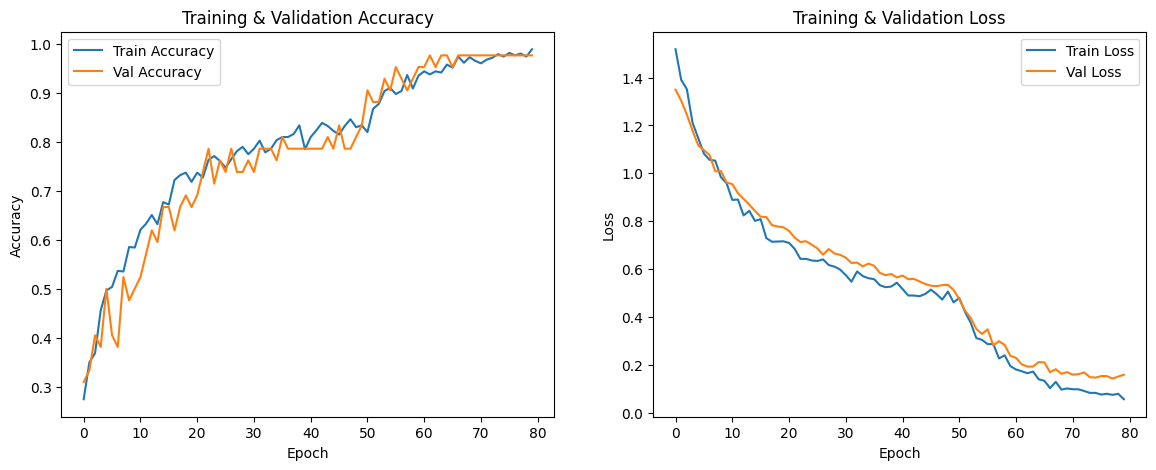

In [4]:
import matplotlib.pyplot as plt

# ==== Gabungkan history stage1 + stage2a ====
def combine_history(h1, h2):
    history = {}
    for key in h1.history.keys():
        history[key] = h1.history[key] + h2.history[key]
    return history

full_history = combine_history(history_stage1, history_stage2)

# ==== Plot Accuracy & Loss ====
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(full_history["accuracy"], label="Train Accuracy")
plt.plot(full_history["val_accuracy"], label="Val Accuracy")
plt.title("Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(full_history["loss"], label="Train Loss")
plt.plot(full_history["val_loss"], label="Val Loss")
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3/3 ━━━━━━━━━━━━━━━━━━━━ 44s 8s/step - accuracy: 0.8899 - loss: 0.3725 - top_2_acc: 1.0000
Test Loss      : 0.3039
Test Accuracy  : 0.9048
Test Top-2 Acc : 1.0000
3/3 ━━━━━━━━━━━━━━━━━━━━ 46s 11s/step

=== Classification Report (Test Data) ===
              precision    recall  f1-score   support

          -K       0.93      0.93      0.93        15
          -N       1.00      0.73      0.84        11
          -P       0.87      1.00      0.93        13
          FN       0.75      1.00      0.86         3

    accuracy                           0.90        42
   macro avg       0.89      0.92      0.89        42
weighted avg       0.92      0.90      0.90        42



<Figure size 700x700 with 0 Axes>

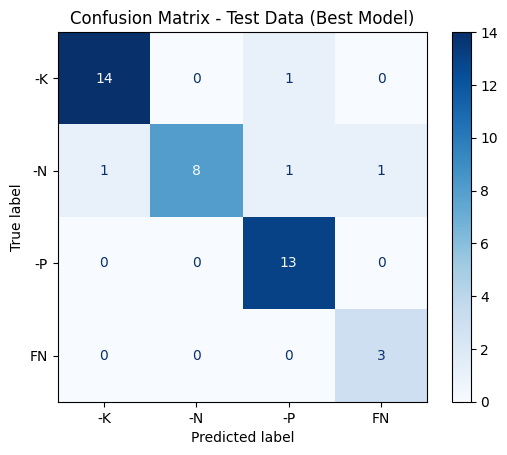

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf

# ==== Load best model dari checkpoint ====
best_model = tf.keras.models.load_model("hybrid_stage2.keras")

# ==== Evaluasi di dataset test ====
test_loss, test_acc, test_top2 = best_model.evaluate(test_gen, verbose=1)
print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test Top-2 Acc : {test_top2:.4f}")

# ==== Prediksi kelas di test set ====
test_gen.reset()
test_preds = best_model.predict(test_gen, verbose=1)
test_pred_classes = np.argmax(test_preds, axis=1)
test_true_classes = test_gen.classes

# ==== Classification Report ====
print("\n=== Classification Report (Test Data) ===")
print(classification_report(test_true_classes, test_pred_classes, target_names=test_gen.class_indices.keys()))

# ==== Confusion Matrix ====
cm = confusion_matrix(test_true_classes, test_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_gen.class_indices.keys())

plt.figure(figsize=(7, 7))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Test Data (Best Model)")
plt.show()

In [7]:
# ==== Simpan model dalam format .keras ====
best_model.save("/content/drive/MyDrive/saved_model_hybrid.keras")

# ==== Konversi ke TFLite ====
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()

# Simpan ke Google Drive
with open("/content/drive/MyDrive/model_hybrid.tflite", "wb") as f:
    f.write(tflite_model)

print("Model sudah tersimpan di Google Drive!")

Saved artifact at '/tmp/tmpxssv5vth'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133021054016528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133021054016912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133021054014992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133021054013840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133021054013648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133021054012880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133021054014608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133021054013456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133030240827152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133021054013264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1330279341456